<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/nifty100_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q


In [2]:

# ================================
# AngelOne Nifty 100 Stock Data - Last 1 Year
# ================================

from SmartApi import SmartConnect
import pyotp
from logzero import logger
import time
import urllib
import json
import pandas as pd
import datetime as dt

# ----------------
# API Credentials
# ----------------
api_key = 'xOHnB7MG'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)



In [3]:
# Token Authentication
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"


data = smartApi.generateSession(username, pwd, totp)

if not data.get('status', True):
    raise Exception("Login Failed")


authToken = data['data']['jwtToken']
refreshToken = data['data']['refreshToken']
feedToken = smartApi.getfeedToken()
smartApi.generateToken(refreshToken)

# -------------------------
# Nifty 100 Stock List
# -------------------------
# Replaced ETF list with Nifty 100 Constituents
tokens = {
    "RELIANCE": "2885", "HDFCBANK": "1333", "ICICIBANK": "4963", "BHARTIARTL": "10604", "SBIN": "3045",
    "INFY": "1594", "LICI": "11802", "ITC": "1660", "TCS": "11536", "LT": "11483",
    "HINDUNILVR": "1330", "AXISBANK": "5900", "KOTAKBANK": "1922", "SUNPHARMA": "3351", "M&M": "2031",
    "HCLTECH": "1348", "TITAN": "3506", "TATASTEEL": "3499", "BAJFINANCE": "317", "ADANIENT": "25",
    "MARUTI": "10999", "ULTRACEMCO": "11532", "POWERGRID": "14977", "NTPC": "11630", "ASIANPAINT": "236",
    "ADANIPORTS": "15083", "BAJAJFINSV": "16675", "JSWSTEEL": "11723", "ONGC": "2475", "TATARECOVERY": "3432",
    "GRASIM": "1232", "COALINDIA": "20374", "NESTLEIND": "17963", "ADANIPOWER": "11561", "TATAMOTORS": "3456",
    "HINDALCO": "1363", "BAJAJ-AUTO": "16669", "SBILIFE": "21808", "ADANIGREEN": "13426", "HAL": "2303",
    "BEL": "383", "BPCL": "526", "TECHM": "13538", "JIOFIN": "24244", "INDUSINDBK": "5258",
    "ZOMATO": "5097", "TRENT": "1964", "BRITANNIA": "547", "VBL": "17132", "DLF": "14732",
    "GAIL": "4717", "GODREJCP": "10099", "HDFCLIFE": "467", "IOC": "1624", "BANKBARODA": "4668",
    "CHOLAFIN": "685", "PIDILITIND": "2664", "PNB": "10666", "SHRIRAMFIN": "10245", "DRREDDY": "881",
    "ADANIENSOL": "14418", "DIVISLAB": "798", "HAVELLS": "9819", "EICHERMOT": "910", "SIEMENS": "3150",
    "APOLLOHOSP": "157", "BAJAJHLDNG": "305", "TVSMOTOR": "3721", "TATACONSUM": "3432", "MANKIND": "15822",
    "LTIM": "17818", "INDIGO": "11195", "AMBUJACEM": "1270", "BOSCHLTD": "469", "UNITDSPR": "3558",
    "VEDL": "3063", "RECLTD": "15355", "TATACHEM": "3405", "JSWENERGY": "13517", "CANBK": "10794",
    "PFC": "14299", "ZydusLife": "242", "HINDZINC": "1444", "ABB": "11", "SOLARINDS": "13262",
    "DMART": "19913", "IRFC": "160", "HEROMOTOCO": "1348", "SRF": "3271", "POLYCAB": "9590",
    "ICICIPRULI": "18652", "COLPAL": "694", "MUTHOOTFIN": "23650", "BERGEPAINT": "404", "MARICO": "1394",
    "NAUKRI": "13751", "PIIND": "2412", "AUROPHARMA": "275", "TATACOMM": "13324", "YESBANK": "11915"
    }



In [4]:
# -----------------
# Data Fetching
# -----------------
historical_data = {}
end_date = dt.datetime.now().strftime('%Y-%m-%d %H:%M')
start_date = (dt.datetime.now() - dt.timedelta(days=365)).strftime('%Y-%m-%d %H:%M')

for name, token in tokens.items():
    try:
        params = {
            "exchange": "NSE",
            "symboltoken": token,
            "interval": "ONE_DAY",
            "fromdate": start_date,
            "todate": end_date
        }
        res = smartApi.getCandleData(params)
        if res['status'] and res['data']:
            df = pd.DataFrame(res['data'], columns=['date', 'open', 'high', 'low', 'close', 'volume'])
            df['date'] = pd.to_datetime(df['date'])
            df.set_index('date', inplace=True)
            historical_data[name] = df['close']
        time.sleep(0.5)  # Respect API rate limits
    except Exception as e:
        logger.error(f"Error fetching data for {name}: {e}")

/tmp/ipykernel_2460/4106310655.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df_prices.pct_change().dropna()


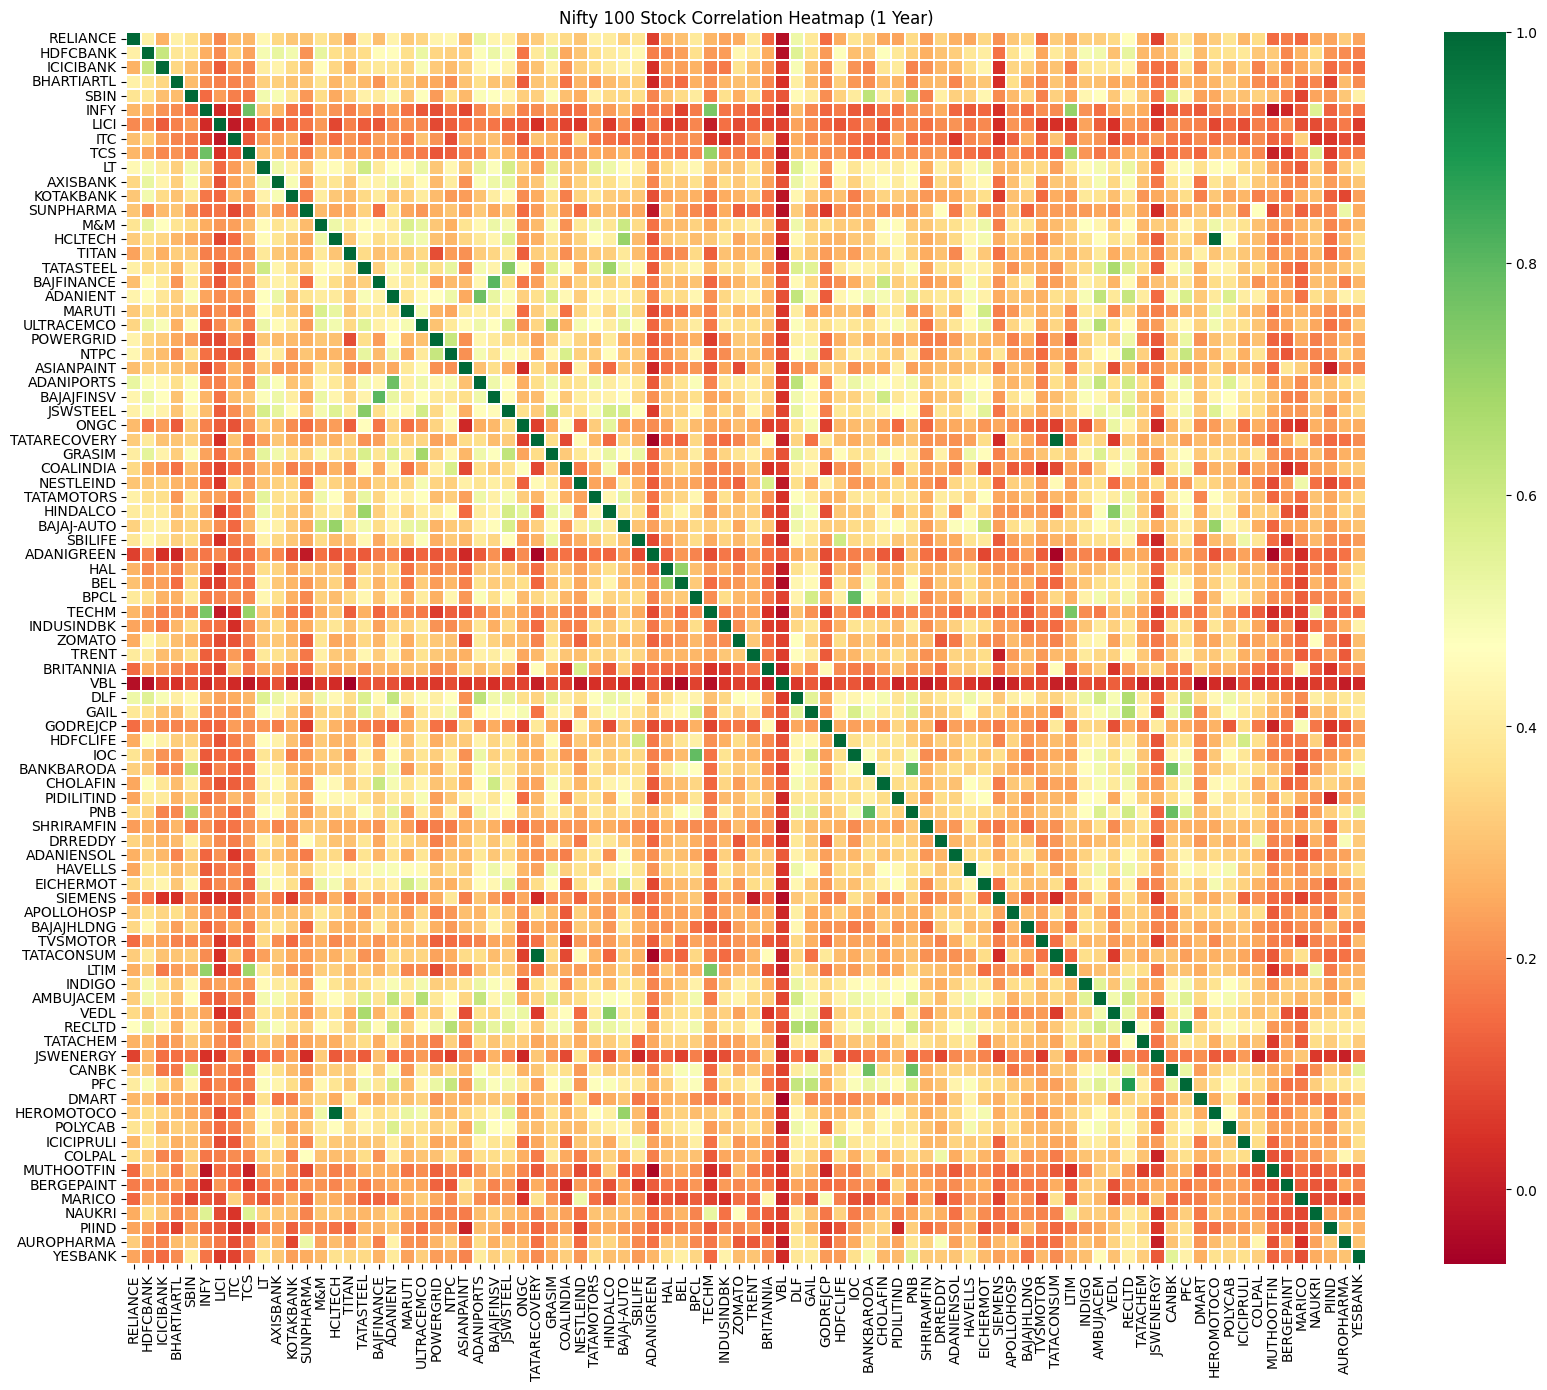

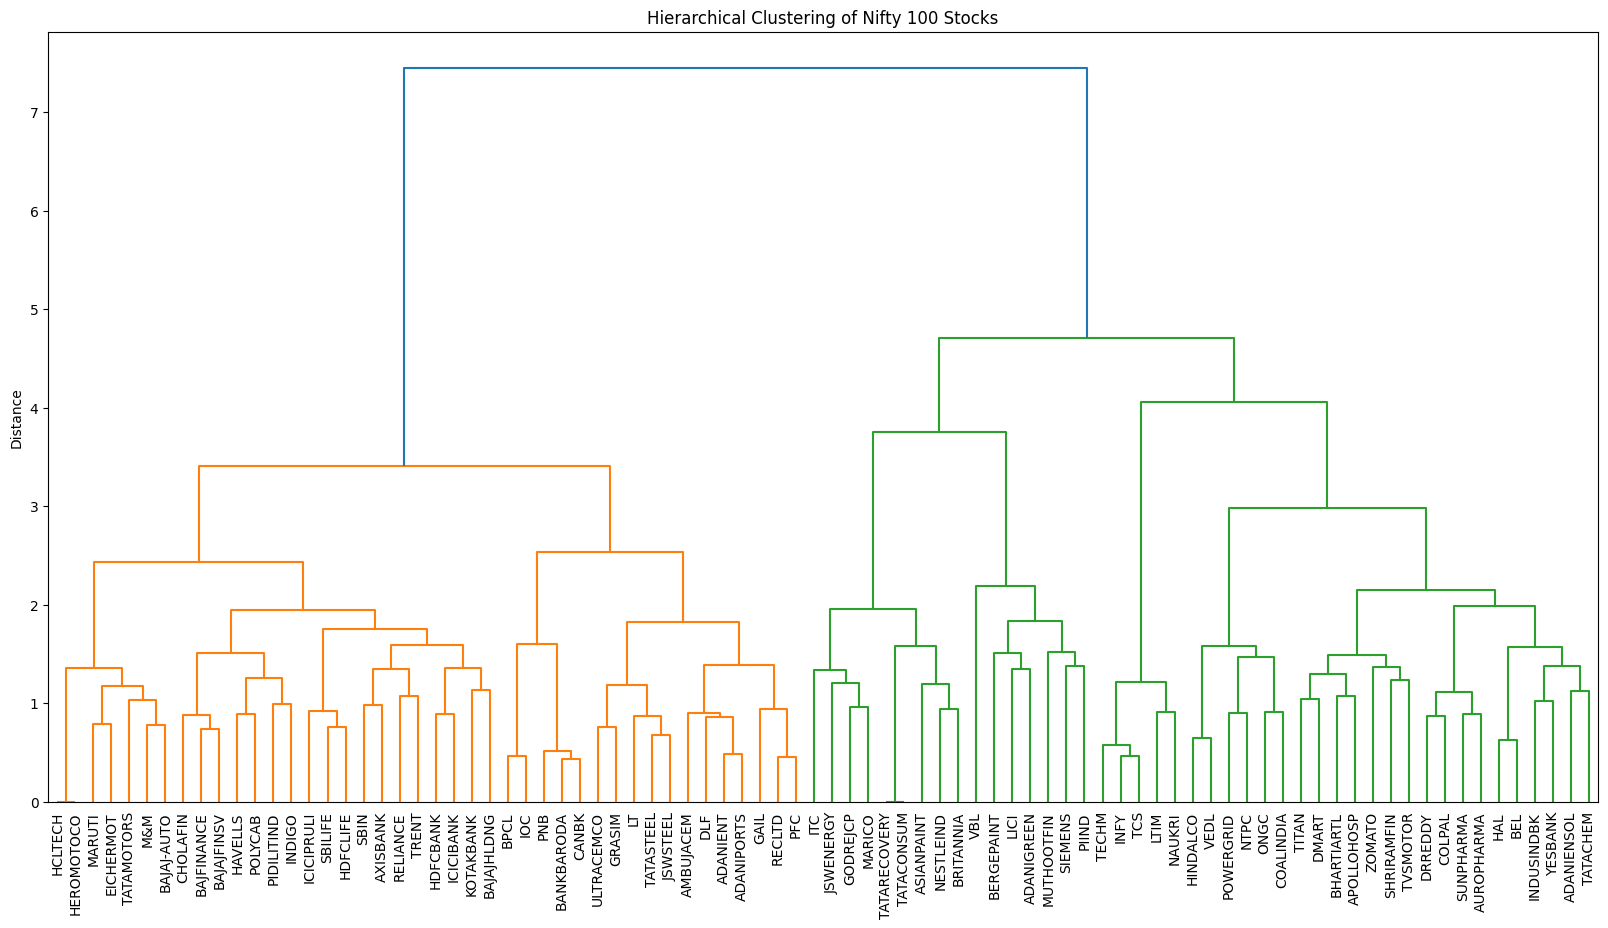

In [5]:
# Create DataFrame
df_prices = pd.DataFrame(historical_data)

# -----------------------
# Analysis & Visualization
# -----------------------
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate Daily Returns
df_returns = df_prices.pct_change().dropna()

# Correlation Matrix
corr_matrix = df_returns.corr()

# 1. Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', linewidths=0.1)
plt.title('Nifty 100 Stock Correlation Heatmap (1 Year)')
plt.show()

# 2. Hierarchical Clustering (Dendrogram)
plt.figure(figsize=(20, 10))
linked = linkage(corr_matrix, method='ward')
dendrogram(linked, labels=corr_matrix.columns, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Nifty 100 Stocks')
plt.ylabel('Distance')
plt.show()



In [6]:
# 3. Performance Summary Table
summary = pd.DataFrame({
    'Total Return (%)': (df_prices.iloc[-1] / df_prices.iloc[0] - 1) * 100,
    'Annualized Volatility (%)': df_returns.std() * (252 ** 0.5) * 100,
    'Sharpe Ratio': (df_returns.mean() / df_returns.std()) * (252 ** 0.5)
}).sort_values(by='Sharpe Ratio', ascending=False)

print("\nPerformance Summary (Top 10 by Sharpe Ratio):")
print(summary.head(10))


Performance Summary (Top 10 by Sharpe Ratio):
            Total Return (%)  Annualized Volatility (%)  Sharpe Ratio
SBIN               37.330053                  20.736038      1.670979
CANBK              52.292248                  28.783339      1.642149
TITAN              30.821175                  20.942775      1.419293
HCLTECH            40.228788                  27.323217      1.403749
HEROMOTOCO         40.228788                  27.323217      1.403749
BEL                37.518709                  27.927380      1.307530
EICHERMOT          30.804845                  23.327295      1.295869
POLYCAB            36.967919                  28.423662      1.275793
VEDL               41.769874                  32.851976      1.255056
MUTHOOTFIN         42.016339                  36.967411      1.158100


In [7]:
# 3. Performance Summary Table
summary = pd.DataFrame({
    'Total Return (%)': (df_prices.iloc[-1] / df_prices.iloc[0] - 1) * 100,
    'Annualized Volatility (%)': df_returns.std() * (252 ** 0.5) * 100,
    'Sharpe Ratio': (df_returns.mean() / df_returns.std()) * (252 ** 0.5)
}).sort_values(by='Sharpe Ratio', ascending=True)

print("\nPerformance Summary (Bottom 10 by Sharpe Ratio):")
print(summary.head(10))


Performance Summary (Bottom 10 by Sharpe Ratio):
            Total Return (%)  Annualized Volatility (%)  Sharpe Ratio
TCS               -34.887160                  21.407202     -1.943899
SHRIRAMFIN        -41.803905                  30.851891     -1.637485
ITC               -27.781170                  19.322377     -1.626445
JSWENERGY         -28.901784                  26.070522     -1.210143
TATACHEM          -26.256192                  24.375023     -1.158145
NAUKRI            -30.834696                  29.055970     -1.154482
TRENT             -35.840879                  35.870397     -1.082119
AMBUJACEM         -22.291820                  24.144617     -0.948342
GAIL              -23.331130                  25.741995     -0.927665
RECLTD            -24.388556                  28.901363     -0.846416


[*********************100%***********************]  8 of 8 completed


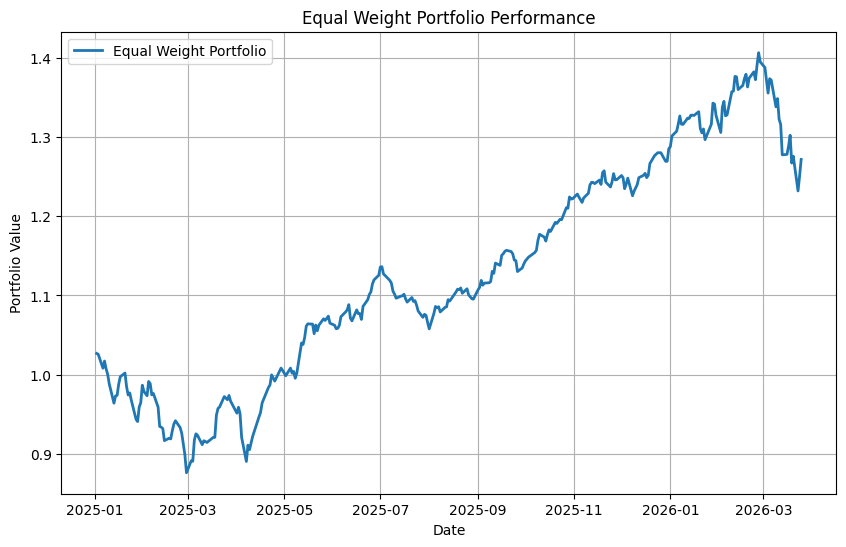

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Stock universe (NSE tickers)
# -----------------------------
tickers = [
    "sbin.NS",
    "bel.NS",
    "hcltech.NS",
    "titan.NS",
    "sbilife.NS",
    "vedl.NS",
    'polycab.ns',
    'EICHERMOT.ns'
]

# -----------------------------
# Download price data
# -----------------------------
data = yf.download(
    tickers,
    start="2025-01-01",
    auto_adjust=True
)["Close"]

# -----------------------------
# Compute daily returns
# -----------------------------
returns = data.pct_change().dropna()

# -----------------------------
# Equal weight portfolio
# -----------------------------
n = len(tickers)
weights = [1/n] * n

portfolio_returns = returns.dot(weights)

# -----------------------------
# Portfolio equity curve
# -----------------------------
portfolio_curve = (1 + portfolio_returns).cumprod()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(portfolio_curve, label="Equal Weight Portfolio", linewidth=2)

plt.title("Equal Weight Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()

plt.show()